# Assignment 2 — Linear Regression

**SVNIT — Department of Artificial Intelligence**

**Question sheet:** `Assignment-2.pdf`  
**Dataset:** `../data/train.csv`


In [9]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

ROOT = Path("..").resolve()
DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"
PLOTS = ROOT / "plots"


def section(title):
    print("\n" + "=" * 64)
    print(f"  {title}")
    print("=" * 64)


def subsection(title):
    print(f"\n--- {title} ---")


def pct(value, digits=2):
    """Format a 0-1 score as a percentage string."""
    return f"{100 * value:.{digits}f}%"


def money(value):
    return f"${value:,.2f}"


def show_plot(name, subfolder):
    folder = PLOTS / subfolder
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / name
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"[saved plot] {path.relative_to(ROOT)}")


def print_regression_metrics(y_true, y_pred, label="Test set"):
    """Print regression errors in both absolute and percentage terms."""
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    mean_y = y_true.mean()
    var_y = y_true.var()
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Percentage views of the errors
    rmse_pct = (rmse / mean_y) * 100
    mae_pct = (mae / mean_y) * 100
    mse_pct_of_variance = (mse / var_y) * 100 if var_y else np.nan

    print(f"\n{label} metrics:")
    print(f"{'Metric':<28} {'Absolute':>16} {'As %':>12}")
    print("-" * 58)
    print(f"{'R² (variance explained)':<28} {r2:>16.4f} {pct(r2):>12}")
    print(f"{'MAE (avg abs error)':<28} {money(mae):>16} {mae_pct:>11.2f}% of mean price")
    print(f"{'RMSE (typical error)':<28} {money(rmse):>16} {rmse_pct:>11.2f}% of mean price")
    print(f"{'MSE (squared error)':<28} {mse:>16,.0f} {mse_pct_of_variance:>11.2f}% of target variance")
    print(f"{'MAPE (avg % error)':<28} {'—':>16} {mape:>11.2f}%")

    return {
        "r2": r2,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "rmse_pct": rmse_pct,
        "mse_pct_of_variance": mse_pct_of_variance,
    }


print(f"Project root: {ROOT}")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

(PLOTS / "assignment_2").mkdir(parents=True, exist_ok=True)



Project root: /Users/ojas/Desktop/ML Lab


## Part A: Exploratory Data Analysis



  Part A: Exploratory Data Analysis
Rows used for modeling: 1,460
Target: SalePrice
Predictors: ['GrLivArea', 'OverallQual', 'GarageCars']

Target skewness: 1.883  →  right-skewed
Target mean:     $180,921.20
Target median:   $163,000.00


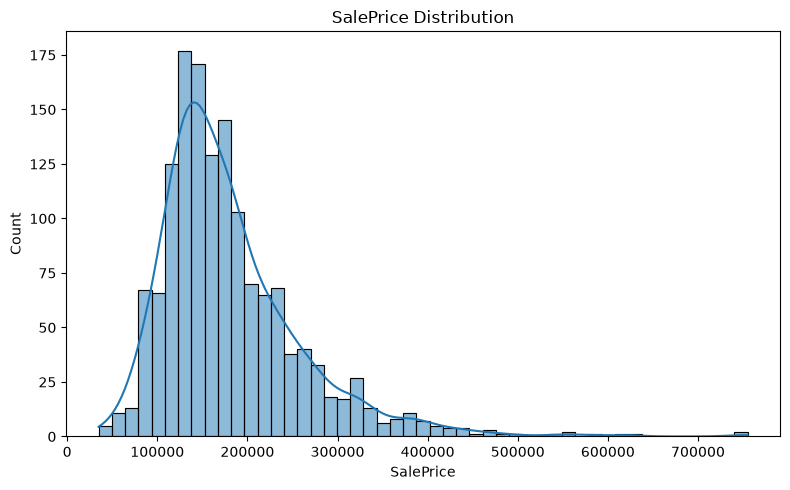

[saved plot] plots/assignment_2/target_distribution.png


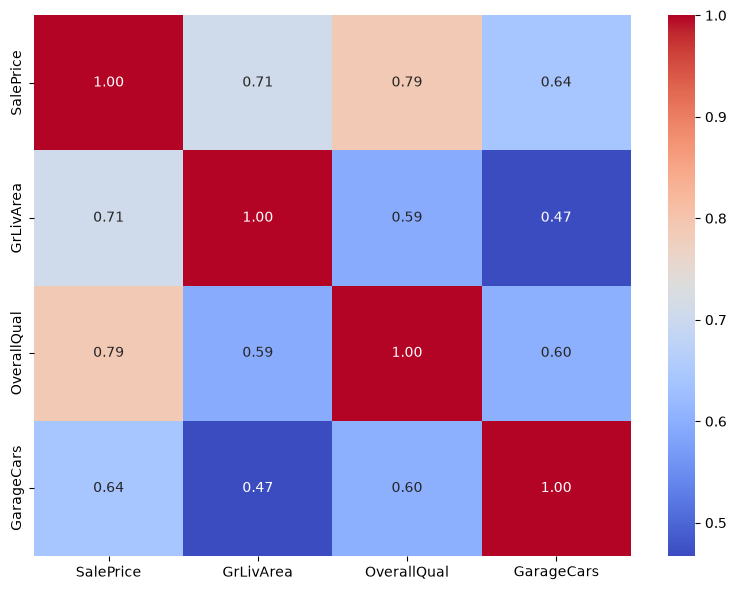

[saved plot] plots/assignment_2/correlation_heatmap.png

Correlation with SalePrice:
Feature               r  |r| %
--------------------------------
GrLivArea        +0.709  70.86%
OverallQual      +0.791  79.10%
GarageCars       +0.640  64.04%


In [10]:
section("Part A: Exploratory Data Analysis")

df = pd.read_csv(DATA / "train.csv")
target = "SalePrice"
features = ["GrLivArea", "OverallQual", "GarageCars"]
model_df = df[[target] + features].dropna()

print(f"Rows used for modeling: {len(model_df):,}")
print(f"Target: {target}")
print(f"Predictors: {features}")

skew = model_df[target].skew()
print(f"\nTarget skewness: {skew:.3f}  →  {'right-skewed' if skew > 0.5 else 'approximately symmetric'}")
print(f"Target mean:     {money(model_df[target].mean())}")
print(f"Target median:   {money(model_df[target].median())}")

plt.figure(figsize=(8, 5))
sns.histplot(model_df[target], kde=True)
plt.title("SalePrice Distribution")
show_plot("target_distribution.png", "assignment_2")

corr = model_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
show_plot("correlation_heatmap.png", "assignment_2")

print("\nCorrelation with SalePrice:")
print(f"{'Feature':<14} {'r':>8}  {'|r| %'}")
print("-" * 32)
for feat, r in corr[target].drop(target).items():
    print(f"{feat:<14} {r:>+8.3f}  {pct(abs(r))}")



## Part B: Simple Linear Regression



  Part B: Simple Linear Regression
Hypothesis:  y = β₀ + β₁x + ε
Intercept β₀: 24,899.75
Slope     β₁: 102.49
Fitted: SalePrice = 24,899.75 + 102.49 × GrLivArea

Interpretation: +1 sq ft in GrLivArea → $102.49 change in SalePrice (on average).
Mean test SalePrice: $178,839.81  (used as baseline for % errors)


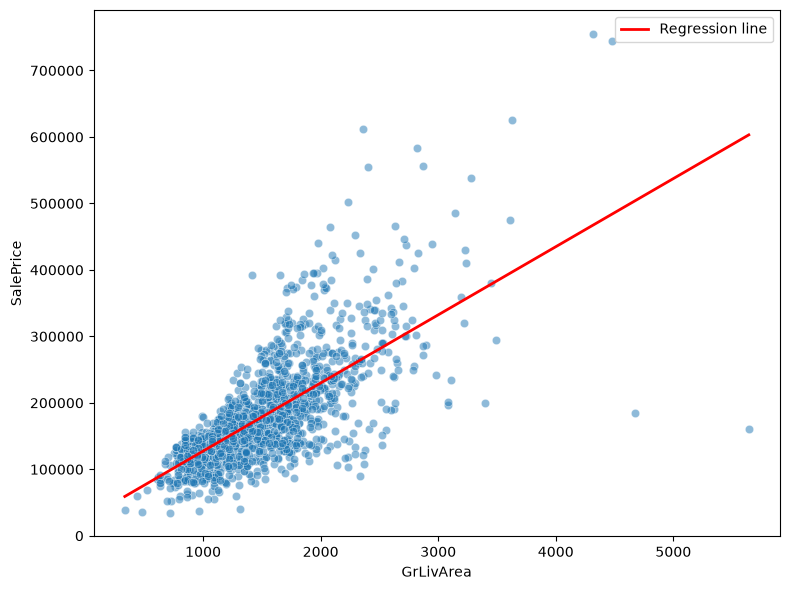

[saved plot] plots/assignment_2/simple_regression.png

Simple Linear Regression (test) metrics:
Metric                               Absolute         As %
----------------------------------------------------------
R² (variance explained)                0.5543       55.43%
MAE (avg abs error)                $38,341.20       21.44% of mean price
RMSE (typical error)               $58,471.76       32.70% of mean price
MSE (squared error)             3,418,946,311       44.57% of target variance
MAPE (avg % error)                          —       23.34%


In [11]:
section("Part B: Simple Linear Regression")

predictor = "GrLivArea"
X_train, X_test, y_train, y_test = train_test_split(
    model_df[[predictor]], model_df[target], test_size=0.2, random_state=42
)

simple = LinearRegression().fit(X_train, y_train)
beta0, beta1 = simple.intercept_, simple.coef_[0]

print("Hypothesis:  y = β₀ + β₁x + ε")
print(f"Intercept β₀: {beta0:,.2f}")
print(f"Slope     β₁: {beta1:,.2f}")
print(f"Fitted: SalePrice = {beta0:,.2f} + {beta1:,.2f} × GrLivArea")
print(f"\nInterpretation: +1 sq ft in GrLivArea → {money(beta1)} change in SalePrice (on average).")
print(f"Mean test SalePrice: {money(y_test.mean())}  (used as baseline for % errors)")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=model_df[predictor], y=model_df[target], alpha=0.5)
x_line = np.linspace(model_df[predictor].min(), model_df[predictor].max(), 100)
plt.plot(x_line, simple.predict(x_line.reshape(-1, 1)), "r", lw=2, label="Regression line")
plt.xlabel(predictor); plt.ylabel(target); plt.legend()
show_plot("simple_regression.png", "assignment_2")

y_hat = simple.predict(X_test)
simple_metrics = print_regression_metrics(y_test, y_hat, label="Simple Linear Regression (test)")



## Part C: Multiple Linear Regression



  Part C: Multiple Linear Regression
Fitted equation:
  SalePrice = -94,208.72 + 47.23×GrLivArea + 26,772.49×OverallQual + 22,239.46×GarageCars

Coefficients:
Feature           Coefficient  Meaning
-------------------------------------------------------
Intercept          -94,208.72
GrLivArea               47.23  +1 unit → $47.23 SalePrice (others fixed)
OverallQual         26,772.49  +1 unit → $26,772.49 SalePrice (others fixed)
GarageCars          22,239.46  +1 unit → $22,239.46 SalePrice (others fixed)

Interpretation (OverallQual): +1 quality point → $26,772.49 SalePrice, holding other predictors fixed.

Multiple Linear Regression (test) metrics:
Metric                               Absolute         As %
----------------------------------------------------------
R² (variance explained)                0.7586       75.86%
MAE (avg abs error)                $28,121.52       15.72% of mean price
RMSE (typical error)               $43,032.15       24.06% of mean price
MSE (squared erro

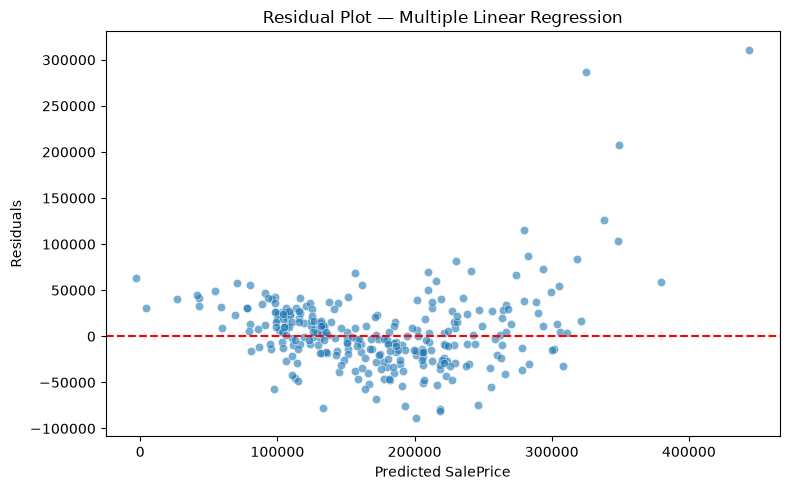

[saved plot] plots/assignment_2/residual_plot.png


In [12]:
section("Part C: Multiple Linear Regression")

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    model_df[features], model_df[target], test_size=0.2, random_state=42
)
multi = LinearRegression().fit(X_train_m, y_train_m)

print("Fitted equation:")
eq = f"  SalePrice = {multi.intercept_:,.2f}"
for f, c in zip(features, multi.coef_):
    eq += f" {'+' if c >= 0 else '-'} {abs(c):,.2f}×{f}"
print(eq)

print("\nCoefficients:")
print(f"{'Feature':<14} {'Coefficient':>14}  Meaning")
print("-" * 55)
print(f"{'Intercept':<14} {multi.intercept_:>14,.2f}")
for f, c in zip(features, multi.coef_):
    print(f"{f:<14} {c:>14,.2f}  +1 unit → {money(c)} SalePrice (others fixed)")

print(f"\nInterpretation (OverallQual): +1 quality point → {money(multi.coef_[1])} SalePrice, holding other predictors fixed.")

y_hat_m = multi.predict(X_test_m)
multi_metrics = print_regression_metrics(y_test_m, y_hat_m, label="Multiple Linear Regression (test)")

subsection("Model comparison")
print(f"{'Model':<22} {'R² %':>8} {'RMSE %':>10} {'MAPE %':>10} {'RMSE ($)':>14}")
print("-" * 68)
print(
    f"{'Simple (GrLivArea)':<22} {pct(simple_metrics['r2']):>8} "
    f"{simple_metrics['rmse_pct']:>9.2f}% {simple_metrics['mape']:>9.2f}% {money(simple_metrics['rmse']):>14}"
)
print(
    f"{'Multiple (3 feats)':<22} {pct(multi_metrics['r2']):>8} "
    f"{multi_metrics['rmse_pct']:>9.2f}% {multi_metrics['mape']:>9.2f}% {money(multi_metrics['rmse']):>14}"
)

r2_gain = multi_metrics["r2"] - simple_metrics["r2"]
rmse_drop_pct = simple_metrics["rmse_pct"] - multi_metrics["rmse_pct"]
print(f"\nWinner: Multiple regression")
print(f"  Extra variance explained: {pct(r2_gain)}")
print(f"  RMSE improvement:         {rmse_drop_pct:.2f} percentage points (relative to mean price)")
print("Why: more predictors capture quality and garage size, so more variance is explained.")

residuals = y_test_m - y_hat_m
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_hat_m, y=residuals, alpha=0.6)
plt.axhline(0, color="r", ls="--")
plt.xlabel("Predicted SalePrice"); plt.ylabel("Residuals")
plt.title("Residual Plot — Multiple Linear Regression")
show_plot("residual_plot.png", "assignment_2")

